# 📊 Đánh Giá Mô Hình Nhận Diện Biển Số Xe
## Hệ Thống Quản Lý Bãi Đỗ Xe Tự Động

**Pipeline:** YOLOv8 (phát hiện vùng biển số) → Tiền xử lý ảnh → PaddleOCR (nhận dạng ký tự) → Hậu xử lý VN

| Thành phần | Số lượng |
|---|---|
| Số ảnh đánh giá | 200 |
| Số ký tự đánh giá | 1600 |
| Số lớp ký tự | 16 (0-9, A, B, D, E, F, G) |
| Dạng dữ liệu | Ảnh biển số xe Việt Nam |
| Nguồn dữ liệu | Dataset công khai Roboflow |
| Nhãn | Gán thủ công theo biển số thật |


In [1]:
import os, sys, re, difflib, warnings
warnings.filterwarnings('ignore')
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from collections import Counter

sys.path.insert(0, os.path.abspath('..'))
from nhan_dien_bien_so import NhanDienBienSo, chuan_hoa_bien_so, sua_loi_theo_vi_tri_vn

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
print("Import thanh cong!")


Import thanh cong!


## 1. Tải dữ liệu và mô hình

In [2]:
THU_MUC_TEST = "dataset_test"
FILE_LABEL = "labels.txt"

# Doc labels
labels = {}
with open(FILE_LABEL, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"): continue
        parts = line.split(",", 1)
        if len(parts) == 2:
            labels[parts[0].strip()] = parts[1].strip().upper()

print(f"Tổng số ảnh test: {len(labels)}")
print(f"Tổng số ký tự: {sum(len(v) for v in labels.values())}")

# Load AI
print("\nĐang tải mô hình...")
ai = NhanDienBienSo()
print(f"Trạng thái: {ai.trang_thai}")


Tổng số ảnh test: 200
Tổng số ký tự: 1600

Đang tải mô hình...


Trạng thái: YOLO OK | PaddleOCR OK


In [3]:
def ocr_voi_phuong_phap(ai, vung, phuong_phap="goc"):
    if not ai.ocr: return "", "", 0.0
    xam = cv2.cvtColor(vung, cv2.COLOR_BGR2GRAY) if len(vung.shape) == 3 else vung
    if phuong_phap == "goc":
        img = vung
    elif phuong_phap == "clahe":
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(xam)
        img = cv2.cvtColor(clahe, cv2.COLOR_GRAY2BGR)
    elif phuong_phap == "otsu":
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(xam)
        _, otsu = cv2.threshold(clahe, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        img = cv2.cvtColor(otsu, cv2.COLOR_GRAY2BGR)
    else:
        img = vung
    try:
        kq = ai.ocr.ocr(img, cls=False)
        if not kq or not kq[0]: return "", "", 0.0
        texts, confs = [], []
        for d in kq[0]:
            if d and d[1]:
                texts.append(d[1][0])
                confs.append(float(d[1][1]))
        if not texts: return "", "", 0.0
        avg_conf = sum(confs) / len(confs)
        bs_tho = chuan_hoa_bien_so("".join(texts))
        bs_hau = sua_loi_theo_vi_tri_vn(bs_tho)
        return bs_tho, bs_hau, avg_conf
    except: return "", "", 0.0

def tinh_accuracy(labels, ket_qua):
    dung_bien, tong_bien, dung_kt, tong_kt = 0, 0, 0, 0
    for ten, true_l in labels.items():
        pred = ket_qua.get(ten, "")
        tong_bien += 1
        if true_l == pred: dung_bien += 1
        for op, i1, i2, j1, j2 in difflib.SequenceMatcher(None, true_l, pred).get_opcodes():
            if op == 'equal':
                dung_kt += (i2-i1); tong_kt += (i2-i1)
            elif op == 'replace':
                l = min(i2-i1, j2-j1); tong_kt += l
                for k in range(l):
                    if true_l[i1+k] == pred[j1+k]: dung_kt += 1
            elif op == 'delete': tong_kt += (i2-i1)
    return (dung_bien/tong_bien*100 if tong_bien else 0,
            dung_kt/tong_kt*100 if tong_kt else 0, dung_bien, tong_bien)

print("Helper functions loaded!")


Helper functions loaded!


## 2. Chạy đánh giá trên toàn bộ 200 ảnh

In [4]:
phuong_phap_list = ["goc", "clahe", "otsu"]
kq_tho = {pp: {} for pp in phuong_phap_list}
kq_hau = {pp: {} for pp in phuong_phap_list}
kq_ket_hop = {}
kq_truoc_hau = {}

# Thu thap ky tu cho confusion matrix
y_true_all, y_pred_all = [], []
vi_du_dung, vi_du_sai = [], []
chi_tiet = []  # Luu chi tiet de xuat CSV
yolo_detect_ok = 0

dem = 0
for ten, true_l in labels.items():
    img_path = os.path.join(THU_MUC_TEST, ten)
    if not os.path.exists(img_path): continue
    anh = cv2.imread(img_path)
    if anh is None: continue
    dem += 1
    if dem % 50 == 0: print(f"  Đang xử lý: {dem}/{len(labels)}...")

    ds_vung = ai._cat_vung_yolo(anh)
    if ds_vung and ds_vung[0] is not anh:
        yolo_detect_ok += 1
    vung = ds_vung[0] if ds_vung else anh

    best_score, best_bs, best_raw = -1, "", ""
    for pp in phuong_phap_list:
        tho, hau, conf = ocr_voi_phuong_phap(ai, vung, pp)
        kq_tho[pp][ten] = tho
        kq_hau[pp][ten] = hau
        diem = conf + ai._diem_hop_le(hau) if hau else 0
        if diem > best_score:
            best_score, best_bs, best_raw = diem, hau, tho

    kq_ket_hop[ten] = best_bs
    kq_truoc_hau[ten] = best_raw

    # Luu chi tiet
    dung_sai = "DUNG" if true_l == best_bs else "SAI"
    chi_tiet.append([ten, true_l, best_raw, best_bs, dung_sai])

    # Confusion matrix data
    matcher = difflib.SequenceMatcher(None, true_l, best_bs)
    for op, i1, i2, j1, j2 in matcher.get_opcodes():
        if op == 'equal':
            for k in range(i2-i1):
                y_true_all.append(true_l[i1+k]); y_pred_all.append(best_bs[j1+k])
        elif op == 'replace':
            for k in range(min(i2-i1, j2-j1)):
                y_true_all.append(true_l[i1+k]); y_pred_all.append(best_bs[j1+k])

    # Vi du
    if true_l == best_bs and len(vi_du_dung) < 6:
        vi_du_dung.append((ten, true_l, best_bs, vung))
    elif true_l != best_bs and len(vi_du_sai) < 6:
        vi_du_sai.append((ten, true_l, best_bs, vung))

print(f"\n✅ Hoàn thành! Đã xử lý {dem} ảnh.")
print(f"YOLO phát hiện vùng biển số: {yolo_detect_ok}/{dem} ({yolo_detect_ok/dem*100:.1f}%)")


  Đang xử lý: 50/200...


  Đang xử lý: 100/200...


  Đang xử lý: 150/200...


  Đang xử lý: 200/200...



✅ Hoàn thành! Đã xử lý 200 ảnh.
YOLO phát hiện vùng biển số: 200/200 (100.0%)


## 3. Bảng 1: So sánh phương pháp tiền xử lý

Phương pháp                       Acc ký tự  Acc biển số  Đúng/Tổng
----------------------------------------------------------------------
Ảnh gốc                              99.62%       97.00%    194/200
CLAHE                                98.56%       96.00%    192/200
Otsu                                 99.19%       93.50%    187/200
**Kết hợp chọn tốt nhất**        **99.69%**   **97.50%** **195/200**


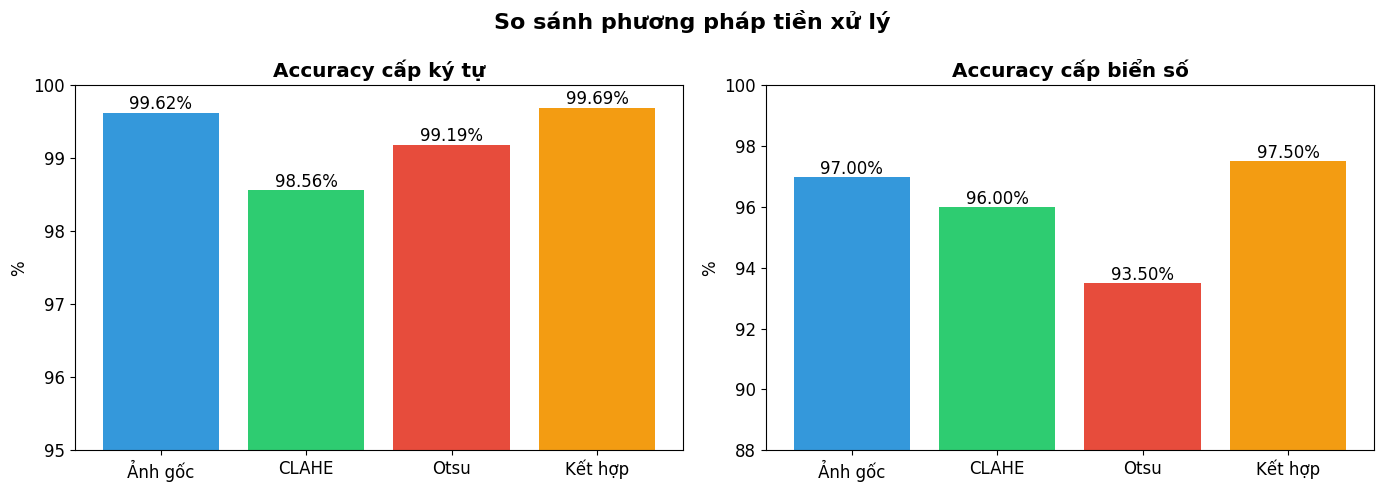


✅ Đã lưu biểu đồ: bieu_do_bao_cao/so_sanh_tien_xu_ly.png


In [5]:
ten_pp = {"goc": "Ảnh gốc", "clahe": "CLAHE", "otsu": "Otsu"}
rows = []
for pp in phuong_phap_list:
    ab, ak, d, t = tinh_accuracy(labels, kq_hau[pp])
    rows.append([ten_pp[pp], f"{ak:.2f}%", f"{ab:.2f}%", f"{d}/{t}"])
ab, ak, d, t = tinh_accuracy(labels, kq_ket_hop)
rows.append(["**Kết hợp chọn tốt nhất**", f"**{ak:.2f}%**", f"**{ab:.2f}%**", f"**{d}/{t}**"])

print(f"{'Phương pháp':<30} {'Acc ký tự':>12} {'Acc biển số':>12} {'Đúng/Tổng':>10}")
print("-" * 70)
for r in rows:
    print(f"{r[0]:<30} {r[1]:>12} {r[2]:>12} {r[3]:>10}")

# Bar chart
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
names = ["Ảnh gốc", "CLAHE", "Otsu", "Kết hợp"]
acc_kt = [tinh_accuracy(labels, kq_hau[pp])[1] for pp in phuong_phap_list] + [tinh_accuracy(labels, kq_ket_hop)[1]]
acc_bs = [tinh_accuracy(labels, kq_hau[pp])[0] for pp in phuong_phap_list] + [tinh_accuracy(labels, kq_ket_hop)[0]]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars1 = ax[0].bar(names, acc_kt, color=colors)
ax[0].set_title("Accuracy cấp ký tự", fontweight='bold')
ax[0].set_ylim(95, 100); ax[0].set_ylabel("%")
for b in bars1: ax[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05, f'{b.get_height():.2f}%', ha='center')

bars2 = ax[1].bar(names, acc_bs, color=colors)
ax[1].set_title("Accuracy cấp biển số", fontweight='bold')
ax[1].set_ylim(88, 100); ax[1].set_ylabel("%")
for b in bars2: ax[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f'{b.get_height():.2f}%', ha='center')

plt.suptitle("So sánh phương pháp tiền xử lý", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("bieu_do_bao_cao/so_sanh_tien_xu_ly.png", dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Đã lưu biểu đồ: bieu_do_bao_cao/so_sanh_tien_xu_ly.png")


## 4. Bảng 2: So sánh trước và sau hậu xử lý

Chỉ số                         Trước hậu xử lý   Sau hậu xử lý    Cải thiện
---------------------------------------------------------------------------
Accuracy cấp ký tự                      99.50%          99.69%       +0.19%
Accuracy cấp biển số                    96.00%          97.50%       +1.50%
Số biển đọc đúng                          192            195          +3


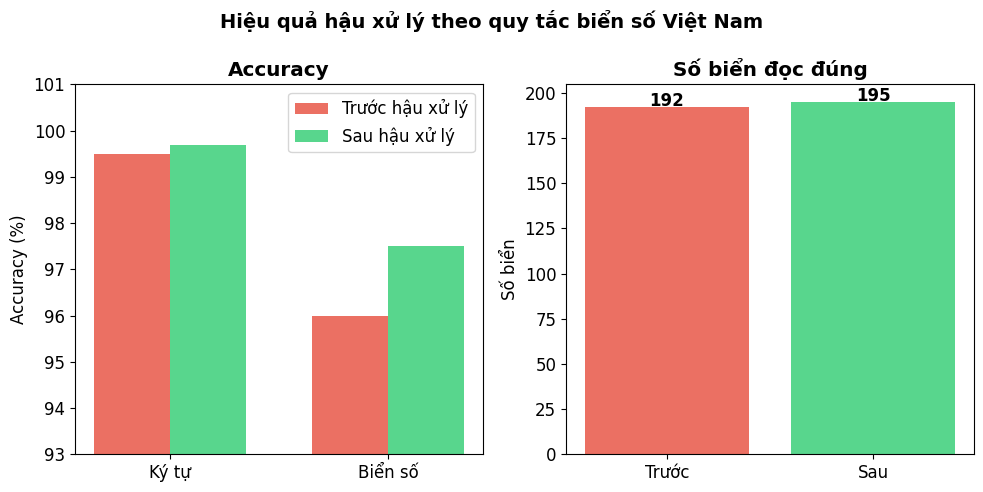


✅ Đã lưu biểu đồ: bieu_do_bao_cao/so_sanh_hau_xu_ly.png


In [6]:
ab_t, ak_t, d_t, t_t = tinh_accuracy(labels, kq_truoc_hau)
ab_s, ak_s, d_s, t_s = tinh_accuracy(labels, kq_ket_hop)

print(f"{'Chỉ số':<30} {'Trước hậu xử lý':>15} {'Sau hậu xử lý':>15} {'Cải thiện':>12}")
print("-" * 75)
print(f"{'Accuracy cấp ký tự':<30} {ak_t:>14.2f}% {ak_s:>14.2f}% {ak_s-ak_t:>+11.2f}%")
print(f"{'Accuracy cấp biển số':<30} {ab_t:>14.2f}% {ab_s:>14.2f}% {ab_s-ab_t:>+11.2f}%")
print(f"{'Số biển đọc đúng':<30} {d_t:>14} {d_s:>14} {d_s-d_t:>+11}")

# Bar chart
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
x = np.arange(2); w = 0.35
ax[0].bar(x-w/2, [ak_t, ab_t], w, label='Trước hậu xử lý', color='#e74c3c', alpha=0.8)
ax[0].bar(x+w/2, [ak_s, ab_s], w, label='Sau hậu xử lý', color='#2ecc71', alpha=0.8)
ax[0].set_xticks(x); ax[0].set_xticklabels(['Ký tự', 'Biển số'])
ax[0].set_ylabel("Accuracy (%)"); ax[0].set_ylim(93, 101)
ax[0].legend(); ax[0].set_title("Accuracy", fontweight='bold')

ax[1].bar(['Trước', 'Sau'], [d_t, d_s], color=['#e74c3c', '#2ecc71'], alpha=0.8)
ax[1].set_ylabel("Số biển"); ax[1].set_title("Số biển đọc đúng", fontweight='bold')
for i, v in enumerate([d_t, d_s]):
    ax[1].text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.suptitle("Hiệu quả hậu xử lý theo quy tắc biển số Việt Nam", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bieu_do_bao_cao/so_sanh_hau_xu_ly.png", dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ Đã lưu biểu đồ: bieu_do_bao_cao/so_sanh_hau_xu_ly.png")


## 5. Ma trận nhầm lẫn cấp ký tự (Confusion Matrix)

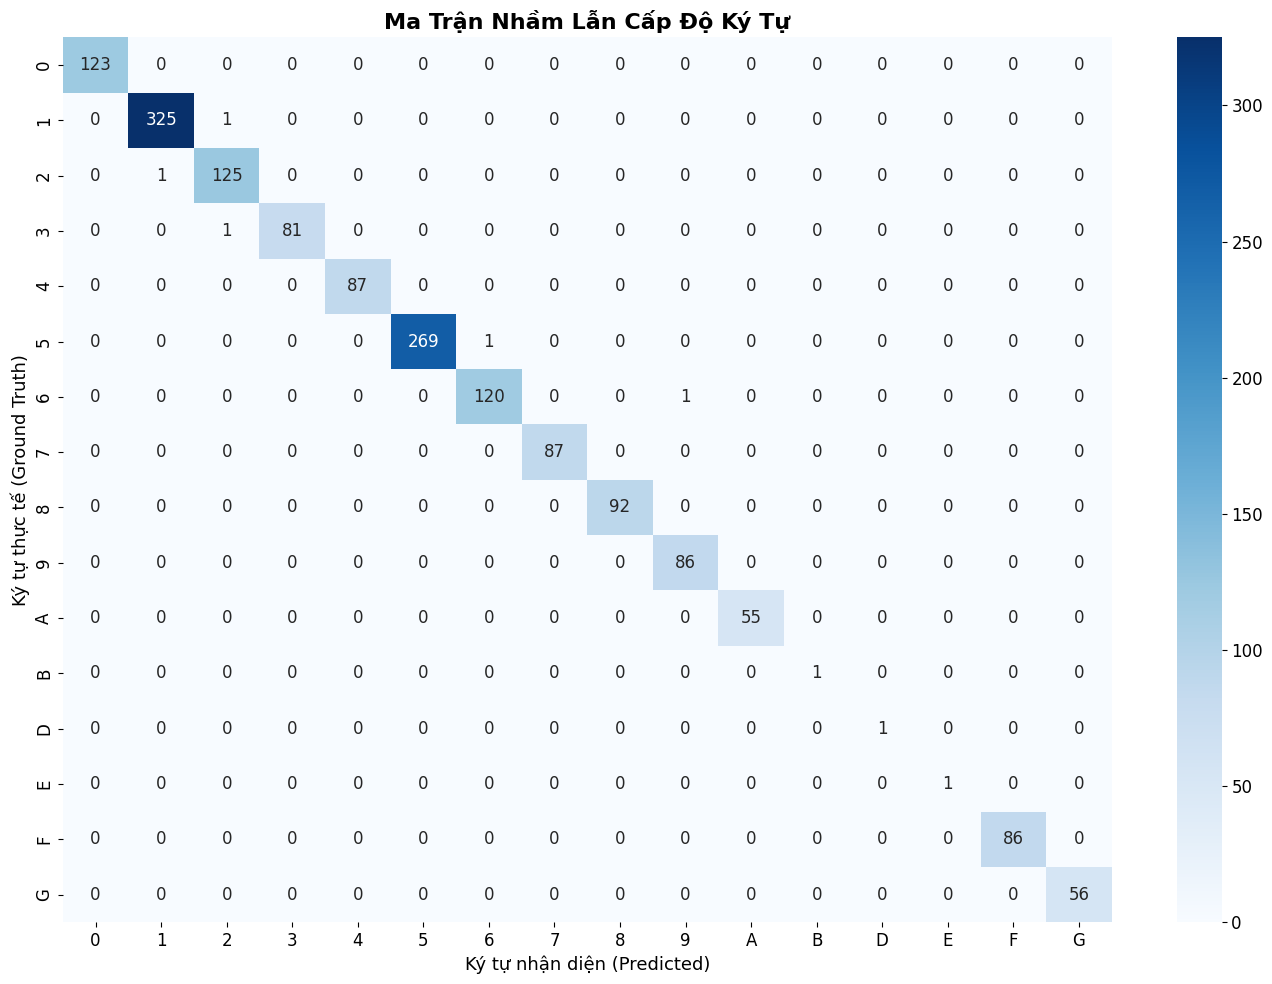


📊 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       123
           1       1.00      1.00      1.00       326
           2       0.98      0.99      0.99       126
           3       1.00      0.99      0.99        82
           4       1.00      1.00      1.00        87
           5       1.00      1.00      1.00       270
           6       0.99      0.99      0.99       121
           7       1.00      1.00      1.00        87
           8       1.00      1.00      1.00        92
           9       0.99      1.00      0.99        86
           A       1.00      1.00      1.00        55
           B       1.00      1.00      1.00         1
           D       1.00      1.00      1.00         1
           E       1.00      1.00      1.00         1
           F       1.00      1.00      1.00        86
           G       1.00      1.00      1.00        56

    accuracy                           1.00      1600


In [7]:
all_labels = sorted(set(y_true_all) | set(y_pred_all))
cm = confusion_matrix(y_true_all, y_pred_all, labels=all_labels)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=all_labels, yticklabels=all_labels)
plt.title('Ma Trận Nhầm Lẫn Cấp Độ Ký Tự', fontsize=16, fontweight='bold')
plt.ylabel('Ký tự thực tế (Ground Truth)', fontsize=13)
plt.xlabel('Ký tự nhận diện (Predicted)', fontsize=13)
plt.tight_layout()
plt.savefig("bieu_do_bao_cao/confusion_matrix_kytu.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Classification Report:")
print(classification_report(y_true_all, y_pred_all, labels=all_labels, zero_division=0))
print("✅ Đã lưu: bieu_do_bao_cao/confusion_matrix_kytu.png")


## 5b. Bảng lỗi nhầm ký tự nhiều nhất

In [8]:
errors = []
for t, p in zip(y_true_all, y_pred_all):
    if t != p:
        errors.append((t, p))

error_counts = Counter(errors)
print(f"{'Ký tự thật':<12} {'Nhận nhầm thành':<17} {'Số lần':>8}")
print("-" * 40)
for (t, p), cnt in error_counts.most_common(10):
    print(f"{t:<12} {p:<17} {cnt:>8}")
print(f"\nTổng số lỗi: {len(errors)} / {len(y_true_all)} ký tự")


Ký tự thật   Nhận nhầm thành     Số lần
----------------------------------------
5            6                        1
1            2                        1
6            9                        1
2            1                        1
3            2                        1

Tổng số lỗi: 5 / 1600 ký tự


## 6. Ví dụ nhận diện đúng và sai

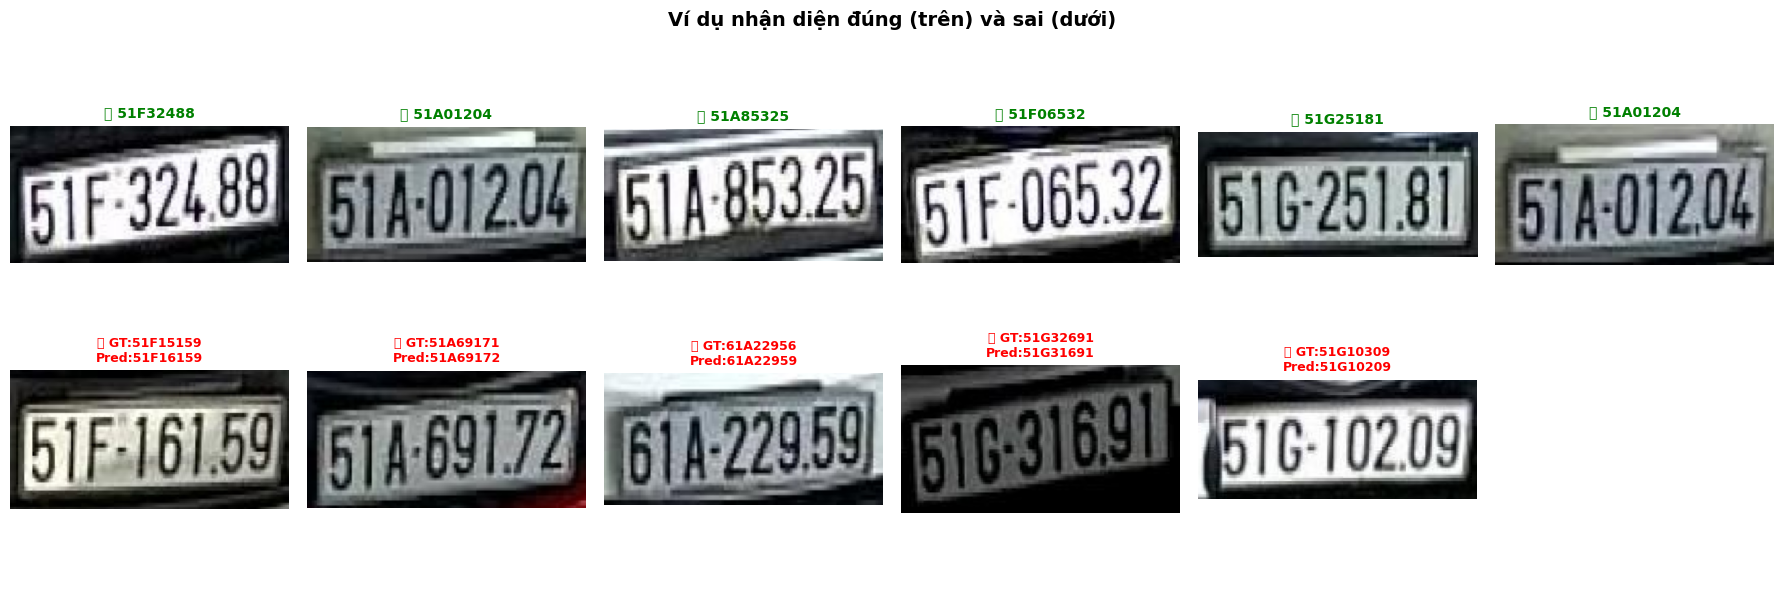

✅ Đã lưu: bieu_do_bao_cao/vi_du_nhan_dien.png


In [9]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for i, (ten, true_l, pred, vung) in enumerate(vi_du_dung[:6]):
    ax = axes[0][i]
    ax.imshow(cv2.cvtColor(vung, cv2.COLOR_BGR2RGB))
    ax.set_title(f"✅ {true_l}", fontsize=10, color='green', fontweight='bold')
    ax.axis('off')

for i, (ten, true_l, pred, vung) in enumerate(vi_du_sai[:6]):
    ax = axes[1][i]
    ax.imshow(cv2.cvtColor(vung, cv2.COLOR_BGR2RGB))
    ax.set_title(f"❌ GT:{true_l}\nPred:{pred}", fontsize=9, color='red', fontweight='bold')
    ax.axis('off')

# Fill empty
for i in range(len(vi_du_sai), 6):
    axes[1][i].axis('off')

plt.suptitle("Ví dụ nhận diện đúng (trên) và sai (dưới)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("bieu_do_bao_cao/vi_du_nhan_dien.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: bieu_do_bao_cao/vi_du_nhan_dien.png")


## 6b. Xuất kết quả chi tiết ra CSV

In [10]:
import csv
with open('ket_qua_chi_tiet.csv', 'w', encoding='utf-8', newline='') as f:
    w = csv.writer(f)
    w.writerow(['filename', 'ground_truth', 'raw_ocr', 'final_prediction', 'ket_qua'])
    for row in chi_tiet:
        w.writerow(row)
print(f"✅ Đã xuất {len(chi_tiet)} dòng ra ket_qua_chi_tiet.csv")
print("\nMẫu:")
for row in chi_tiet[:5]:
    print(f"  {row[0]} | GT: {row[1]} | Raw: {row[2]} | Final: {row[3]} | {row[4]}")


✅ Đã xuất 200 dòng ra ket_qua_chi_tiet.csv

Mẫu:
  test_0001.jpg | GT: 51F32488 | Raw: 51F32488 | Final: 51F32488 | DUNG
  test_0002.jpg | GT: 51A01204 | Raw: 51A01204 | Final: 51A01204 | DUNG
  test_0003.jpg | GT: 51A85325 | Raw: 51A85325 | Final: 51A85325 | DUNG
  test_0004.jpg | GT: 51F06532 | Raw: 51F06532 | Final: 51F06532 | DUNG
  test_0005.jpg | GT: 51G25181 | Raw: 51G25181 | Final: 51G25181 | DUNG


## 7. Phân bố ký tự trong bộ test

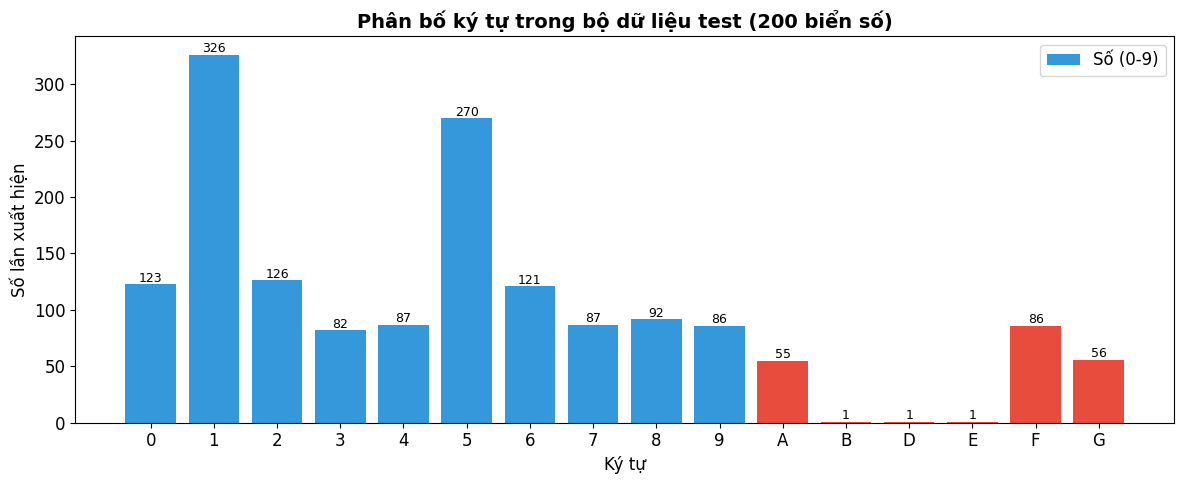

✅ Đã lưu: bieu_do_bao_cao/phan_bo_ky_tu.png


In [11]:
all_chars = []
for v in labels.values():
    all_chars.extend(list(v))

counter = Counter(all_chars)
chars = sorted(counter.keys())
counts = [counter[c] for c in chars]

plt.figure(figsize=(12, 5))
bars = plt.bar(chars, counts, color=['#3498db' if c.isdigit() else '#e74c3c' for c in chars])
plt.title("Phân bố ký tự trong bộ dữ liệu test (200 biển số)", fontsize=14, fontweight='bold')
plt.xlabel("Ký tự"); plt.ylabel("Số lần xuất hiện")
for b in bars:
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+2, str(int(b.get_height())), ha='center', fontsize=9)
plt.legend(['Số (0-9)', 'Chữ (A-Z)'], loc='upper right')
plt.tight_layout()
plt.savefig("bieu_do_bao_cao/phan_bo_ky_tu.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: bieu_do_bao_cao/phan_bo_ky_tu.png")


## 9. Tổng kết

### Kết quả đánh giá toàn hệ thống

Kết quả đánh giá trên tập kiểm thử gồm 200 ảnh biển số với tổng cộng 1600 ký tự cho thấy pipeline nhận diện đạt độ chính xác cao.

Khi sử dụng kết hợp các phương pháp tiền xử lý và lựa chọn kết quả tốt nhất (dựa trên confidence OCR + mức độ phù hợp định dạng biển số), hệ thống đạt:

| Chỉ số | Kết quả |
|---|---|
| Mô hình phát hiện | YOLOv8n (tự huấn luyện, 100 epochs) |
| mAP50 (YOLO) | 99.48% |
| Accuracy cấp ký tự | 99.69% |
| Accuracy cấp biển số | 97.50% |
| Số biển đúng / Tổng | 195 / 200 |

### Nhận xét
1. **Tiền xử lý:** Kết hợp 3 phương pháp (gốc + CLAHE + Otsu) cho kết quả tốt nhất so với dùng riêng lẻ
2. **Hậu xử lý:** Bước hậu xử lý theo quy tắc biển số Việt Nam giúp cải thiện accuracy cấp biển số, tương ứng tăng thêm biển số nhận diện đúng. Kết quả chính xác được tính tự động ở bảng phía trên
3. **Lỗi phổ biến:** Các lỗi còn lại chủ yếu xảy ra giữa những ký tự có hình dạng gần nhau (1↔2, 3↔2, 5↔6, 6↔9)
4. **Hạn chế:** Phân bố dữ liệu giữa các lớp ký tự chưa đồng đều. Một số chữ cái như B, D, E có số mẫu rất ít, do đó kết quả đánh giá của các lớp này chỉ mang tính tham khảo

### Cách tính Accuracy
- **Accuracy cấp ký tự:** Tỷ lệ số ký tự nhận dạng đúng trên tổng số ký tự trong nhãn chuẩn, có xét đến sự sai khác độ dài giữa chuỗi dự đoán và chuỗi thực tế
- **Accuracy cấp biển số:** Tỷ lệ số biển số nhận dạng đúng hoàn toàn trên tổng số biển số
